In [1]:
import warnings
warnings.filterwarnings('ignore')

from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import plot_intervals, circ_bin_average

import numpy as np
import pynapple as nap
import seaborn as sns
import umap
import umap.plot as uplot

from matplotlib import pyplot as plt

# Parameters
WAKE_BIN = 0.2
NREM_BIN = 0.05
WAKE_SMOOTH_STD = 0.4
NREM_SMOOTH_STD = 0.05
UMAP_NEIGHBORS = 250
UMAP_MIN_DIST = 0.2


Load unit data

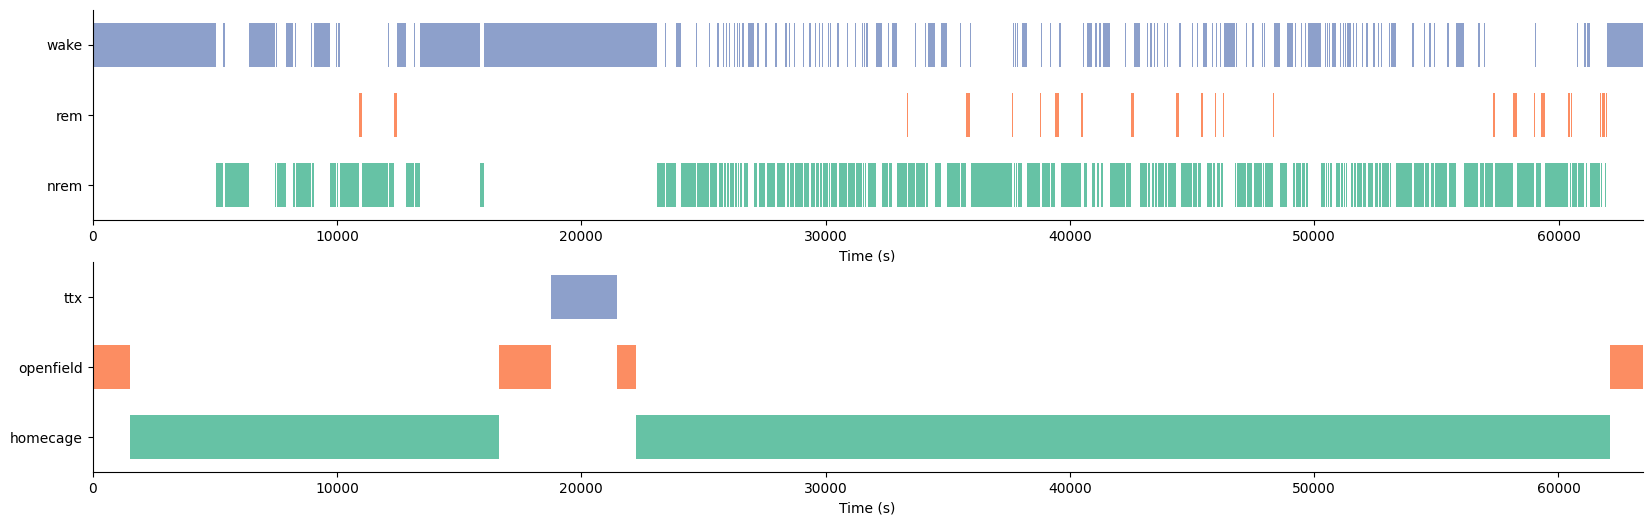

In [2]:
unit_id = "116b"
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

# Plot sleep states and sessions for the unit
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6))

plot_intervals(sleep_states, column='state', palette='Set2', ax=ax1)
plot_intervals(sessions, column='label', palette='Set2', ax=ax2)

plt.show()

### Wake manifold

wake_rates shape: (10548, 81)


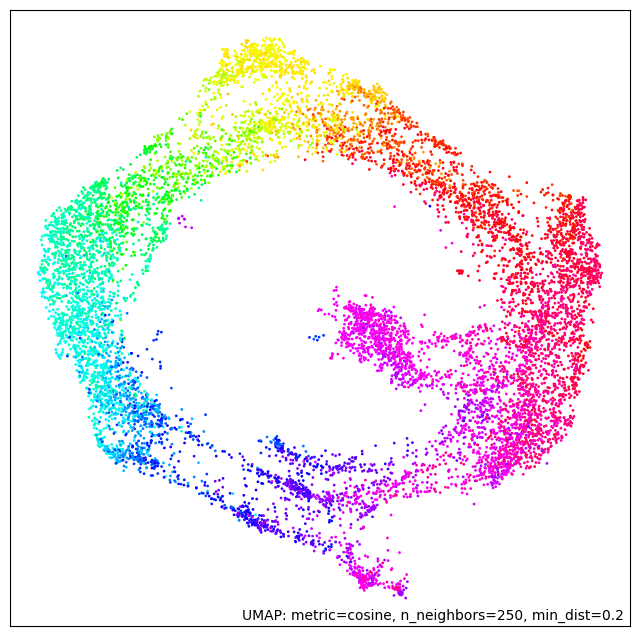

In [3]:
epochs = sessions[sessions['label'] == 'openfield']
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=hd_angle.time_support)
wake_rates = np.sqrt(binned.smooth(std=WAKE_SMOOTH_STD))
angle = circ_bin_average(hd_angle, bin_size=WAKE_BIN)
print(f"wake_rates shape: {wake_rates.shape}")

reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='cosine')
reducer.fit(wake_rates)
uplot.points(reducer, values=angle.values, cmap='hsv')
plt.show()

### Fitting NREM sweep onto the manifold

In [4]:
epochs = nap.IntervalSet(start=[30000], end=[40000])

binned = hd_spikes.count(bin_size=NREM_SMOOTH_STD, ep=epochs)
smooth_rate = np.sqrt(binned.smooth(std=NREM_SMOOTH_STD))
print(f"smooth_rate shape: {smooth_rate.shape}")

embds = reducer.transform(smooth_rate)

smooth_rate shape: (200000, 81)


In [10]:
manifold = nap.TsdFrame(t=smooth_rate.t, d=embds, columns=['x', 'y'])
manifold

Time (s)           x           y
----------  --------  ----------
30000.025   1.73074    0.222965
30000.075   1.88644    0.0164483
30000.125   2.56117    0.251023
30000.175   4.80094   -1.36375
30000.225   5.76377   -1.60814
30000.275   5.81627   -1.18081
30000.325   3.39267    4.97784
...
39999.675   8.82346    1.07723
39999.725   9.02301    0.99577
39999.775   8.65735    2.29807
39999.825   6.30575    2.076
39999.875   1.71641    1.25941
39999.925   0.684467   1.77262
39999.975   0.713453   2.16563
dtype: float32, shape: (200000, 2)

In [12]:
sweeps = [35029, 35052, 37556, 38409]

In [85]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap

husl_cmap = ListedColormap(sns.color_palette("husl", 360), name="husl")
if "husl" in mpl.colormaps:
    mpl.colormaps.unregister("husl")
mpl.colormaps.register(husl_cmap)

In [149]:
from cmap import Colormap

cmaps = ['colorcet:CET_C1', 'colorcet:CET_C11', 'colorcet:CET_C7', 'cmocean:phase',
         'colorcet:CET_C5', 'cmasher:viola', 'colorbrewer:Greys', 'colorbrewer:OrRd']
for cmap_name in cmaps:
    if cmap_name.lower() in mpl.colormaps:
        mpl.colormaps.unregister(cmap_name.lower())
    mpl.colormaps.register(Colormap(cmap_name).to_mpl())

In [ ]:
pref_angle = hd_spikes['preferred_angle'].apply(np.rad2deg)
norm = plt.Normalize()
cmap = Colormap('cmocean:phase').to_mpl()
color = cmap(norm([i / (2 * np.pi) for i in pref_angle.values]))

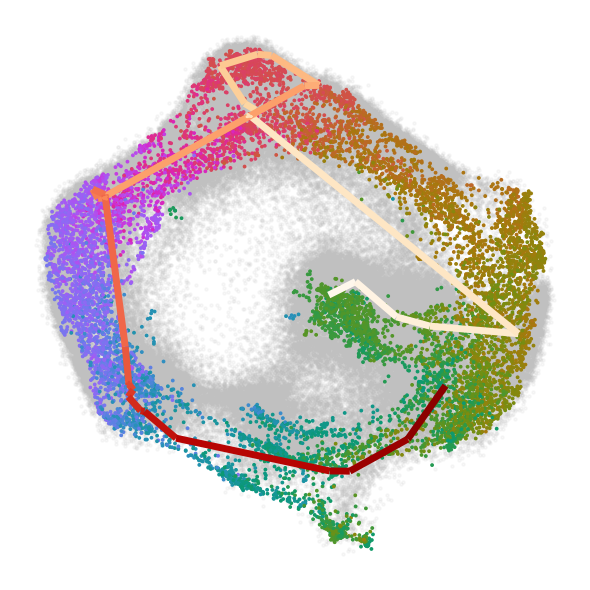

In [377]:
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(6, 6))
index = 2
ep = nap.IntervalSet(start=sweeps[index]-0.5, end=sweeps[index]+1)
ripple = manifold.restrict(ep)

ax.scatter(x=embds[:, 0], y=embds[:, 1], c='#C0C0C0', s=5, alpha=0.1)
ax.scatter(x=reducer.embedding_[:, 0], y=reducer.embedding_[:, 1], c=angle.values,
                 cmap='cmocean:phase', s=3)

# Time-colored trajectory
points = np.column_stack([ripple['x'].values, ripple['y'].values])
segments = np.stack([points[:-1], points[1:]], axis=1)
t = np.array(ripple.t - ripple.t[0])  # time from sweep onset
norm = plt.Normalize(t.min(), t.max())
lc = LineCollection(segments, cmap='colorbrewer:orrd', norm=norm)
lc.set_array(t[:-1])
lc.set_linewidth(5)
ax.add_collection(lc)

# Add arrows every N segments
N = 5  # change to 3 for every 3rd
for i in range(0, len(points) - 1, N):
    dx = points[i+1, 0] - points[i, 0]
    dy = points[i+1, 1] - points[i, 1]
    ax.annotate('',
        xytext=(points[i, 0], points[i, 1]),
        xy=(points[i, 0] + dx, points[i, 1] + dy),
        arrowprops=dict(arrowstyle='->', color=cm.get_cmap('colorbrewer:orrd')(norm(t[i])),
                        lw=2, mutation_scale=5),
    )

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig(INTERIM_DATA_PATH / unit_id / f"sweep_trajectory_example.png", dpi=300, format='png')

In [339]:
from nrem_sc.utils import hd_tuning, circ_colors

spikes = hd_spikes.restrict(ep)
idx = spikes[spikes['rate'] > 0].index
tcs, pref_ang = hd_tuning(hd_spikes, hd_angle)
norm_tcs = (tcs - tcs.min(dim='head_direction')) / (tcs.max(dim='head_direction') - tcs.min(dim='head_direction'))
norm_tcs = norm_tcs.sortby(pref_ang)

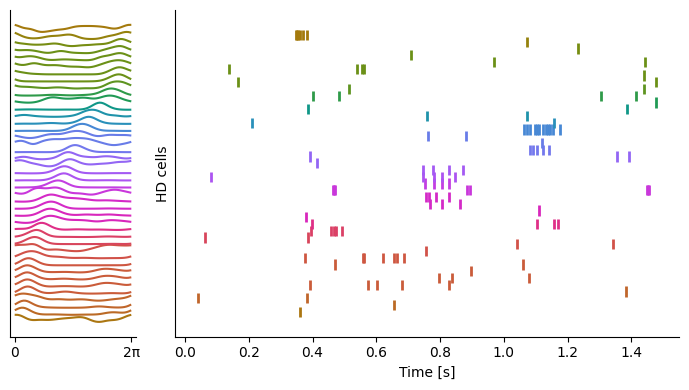

In [375]:
f, axes = plt.subplots(1, 2, figsize=(7, 4), width_ratios=[1, 4])

# Sort preferred angles and derive colors in sorted order
sorted_pref_ang = pref_ang.sortby(pref_ang)
sorted_units = sorted_pref_ang.coords[sorted_pref_ang.dims[0]].values
sorted_colors = cmap(sorted_pref_ang.values / (2 * np.pi))

offset = 0.2
for i, uid in enumerate(sorted_units):
    if uid not in idx:
        continue
    c = sorted_colors[i]

    # Plot normalized tuning curve
    axes[0].plot(tcs['head_direction'], norm_tcs[i, :] + offset, color=c)

    # Plot spike raster at matching y-position
    if uid in spikes.keys():
        spike_times = spikes[uid].t
        axes[1].eventplot(spike_times - ep['start'], lineoffsets=offset + 0.5,
                         linelengths=1.5, linewidths=2, color=c)

    offset += 1

axes[0].set_xticks([0, 2*np.pi], labels=['0', '2π'])
axes[0].set_yticks([])

axes[1].set_yticks([])
axes[1].set_ylabel('HD cells')
axes[1].set_xlabel('Time [s]')
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(INTERIM_DATA_PATH / unit_id / "sweep_example_spiking.svg", dpi=300, format='svg')

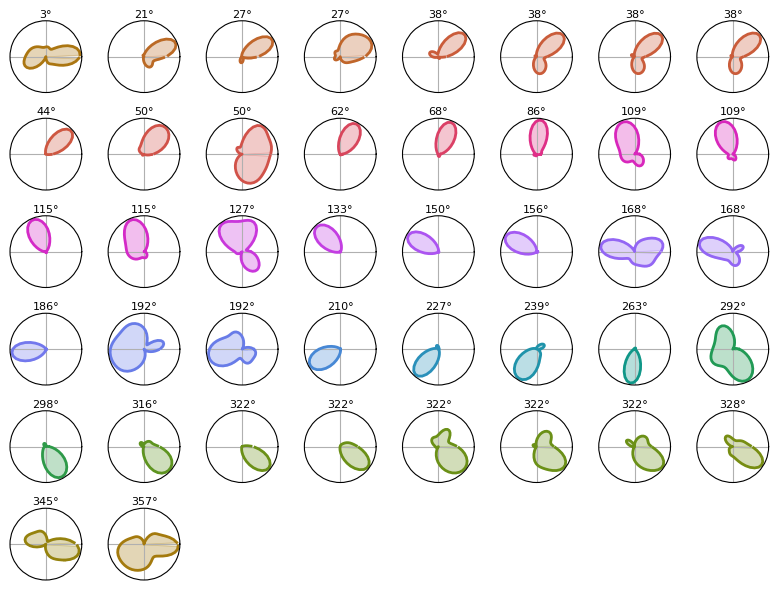

In [379]:
sorted_pref_ang = pref_ang.sortby(pref_ang)
sorted_units = sorted_pref_ang.coords[sorted_pref_ang.dims[0]].values
sorted_colors = cmap(sorted_pref_ang.values / (2 * np.pi))

# Only units that fired in the epoch
active = [uid for uid in sorted_units if uid in idx]
n_active = len(active)
ncols = min(n_active, 8)
nrows = int(np.ceil(n_active / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(1 * ncols, 1 * nrows),
                         subplot_kw={'projection': 'polar'})
axes = np.atleast_2d(axes)

for ax in axes.flat:
    ax.set_visible(False)

for j, uid in enumerate(active):
    i = np.where(sorted_units == uid)[0][0]
    c = sorted_colors[i]
    ax = axes.flat[j]
    ax.set_visible(True)
    ax.plot(tcs['head_direction'].values, norm_tcs[i, :].values, color=c, linewidth=2)
    ax.fill_between(tcs['head_direction'].values, 0, norm_tcs[i, :].values, color=c, alpha=0.3)
    ax.set_yticks([])
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax.set_xticklabels([])
    ax.set_title(f'{np.rad2deg(sorted_pref_ang.sel({sorted_pref_ang.dims[0]: uid}).values):.0f}°',
                 fontsize=8, pad=2)

plt.tight_layout()

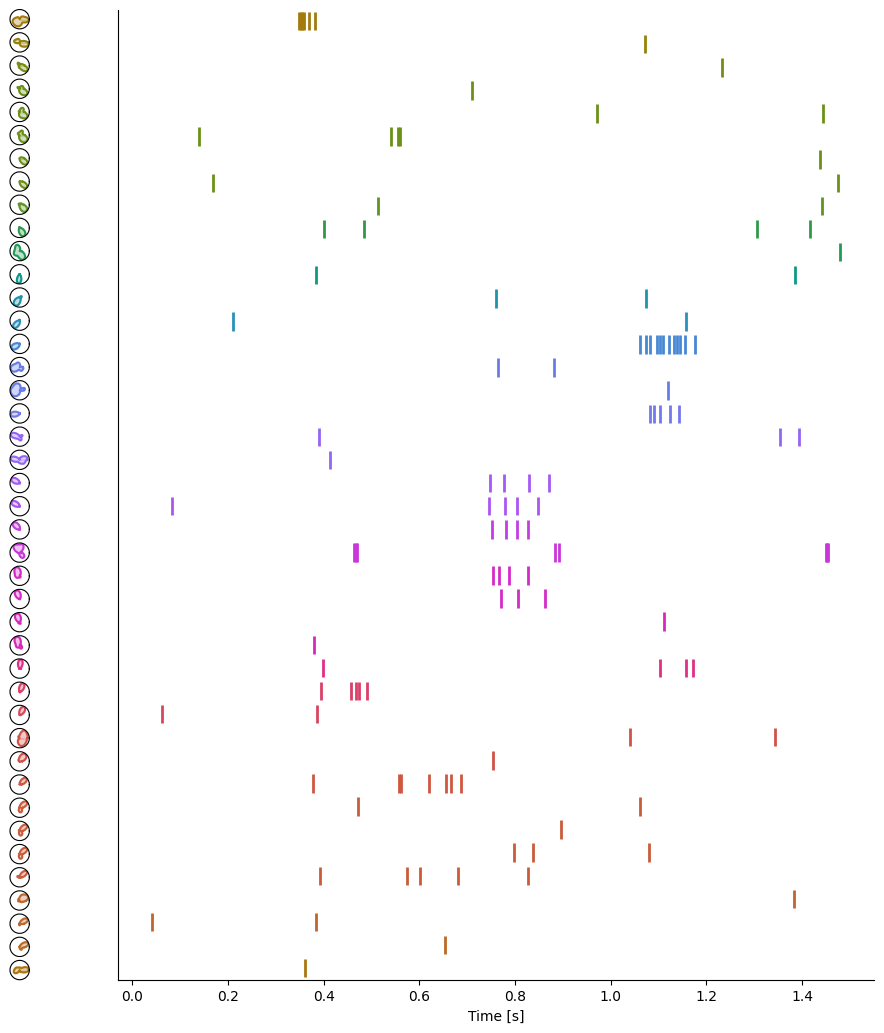

In [348]:
from matplotlib.gridspec import GridSpec

sorted_pref_ang = pref_ang.sortby(pref_ang)
sorted_units = sorted_pref_ang.coords[sorted_pref_ang.dims[0]].values
sorted_colors = cmap(sorted_pref_ang.values / (2 * np.pi))
active = [uid for uid in sorted_units if uid in idx]
n_active = len(active)

fig = plt.figure(figsize=(12, n_active * 0.3))
gs = GridSpec(n_active, 2, width_ratios=[1, 5], wspace=0.05)

# Right panel: spike raster (spans all rows)
ax_raster = fig.add_subplot(gs[:, 1])

for j, uid in enumerate(active):
    i = np.where(sorted_units == uid)[0][0]
    c = sorted_colors[i]

    # Left panel: polar inset per neuron
    ax_polar = fig.add_subplot(gs[n_active - 1 - j, 0], projection='polar')
    ax_polar.plot(tcs['head_direction'].values, norm_tcs[i, :].values, color=c, linewidth=1.5)
    ax_polar.fill_between(tcs['head_direction'].values, 0, norm_tcs[i, :].values, color=c, alpha=0.3)
    ax_polar.set_yticks([])
    ax_polar.set_xticks([])

    # Right panel: spike raster row
    if uid in spikes.keys():
        spike_times = spikes[uid].t
        ax_raster.eventplot(spike_times - ep['start'], lineoffsets=j,
                            linelengths=0.8, linewidths=2, color=c)

ax_raster.set_yticks([])
ax_raster.set_xlabel('Time [s]')
ax_raster.set_ylim(-0.5, n_active - 0.5)
for spine in ['top', 'right']:
    ax_raster.spines[spine].set_visible(False)

plt.tight_layout()

In [ ]:
import pandas as pd
# window = nap.IntervalSet(start=[35000], end=[40000])
classified_hd = nap.TsdFrame(pd.read_csv(PROCESSED_DATA_PATH / unit_id / "post_ttx_decoded_states.csv", index_col=0))
tdf = classified_hd.restrict(ep)

In [362]:
sweep_ep = tdf['continuous'].threshold(0.5).time_support

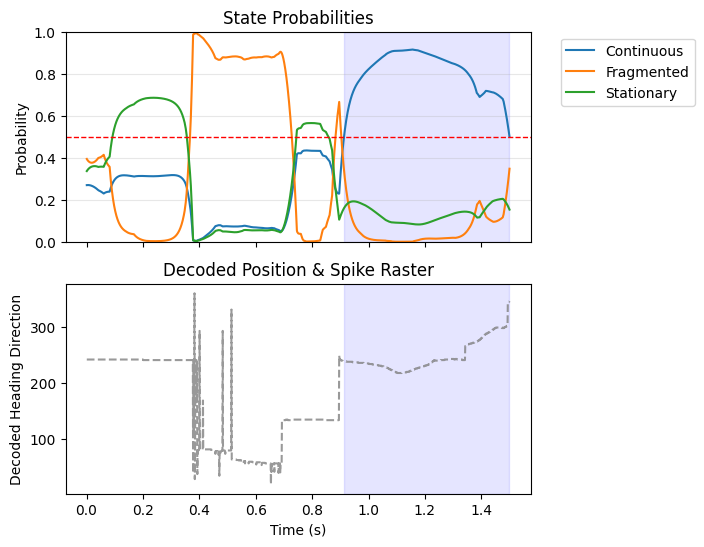

In [381]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

t = tdf.times() - ep['start']

# state probabilities
ax[0].plot(t, tdf['continuous'], label='Continuous', color='tab:blue')
ax[0].plot(t, tdf['fragmented'], label='Fragmented', color='tab:orange')
ax[0].plot(t, tdf['stationary'], label='Stationary', color='tab:green')
ax[0].axhline(0.5, color='r', linestyle='--', linewidth=1)
ax[0].set_ylim(0, 1)
ax[0].set_ylabel('Probability')
ax[0].set_title('State Probabilities')
ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].grid(axis='y', alpha=0.3)


# decoded position
ax[1].plot(t, tdf['position'], label='Decoded Position', color='gray', alpha=0.8, linestyle='--')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Decoded Heading Direction')
ax[1].set_title('Decoded Position & Spike Raster')
# ax[1].hlines([0, 359], color='k', xmin=t.min(), xmax=t.max(), linestyle='--', linewidth=1)

for a in ax:
    a.axvspan((sweep_ep['start'] - ep['start']).item(), (sweep_ep['end'] - ep['start']).item(), color='blue', alpha=0.1)

plt.savefig(INTERIM_DATA_PATH / unit_id / f"sweep_decoding_example.svg", dpi=300, format='svg')